In [1]:
!pip install opencv-python
!pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 22.6 MB/s eta 0:00:00


## Deteksi satu wajah

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

In [3]:
from google.colab import drive
drive.mount('/content/drive')
path = "/content/drive/MyDrive/GoogleColab_ComputerVision/Tugas3/Dataset"

Mounted at /content/drive


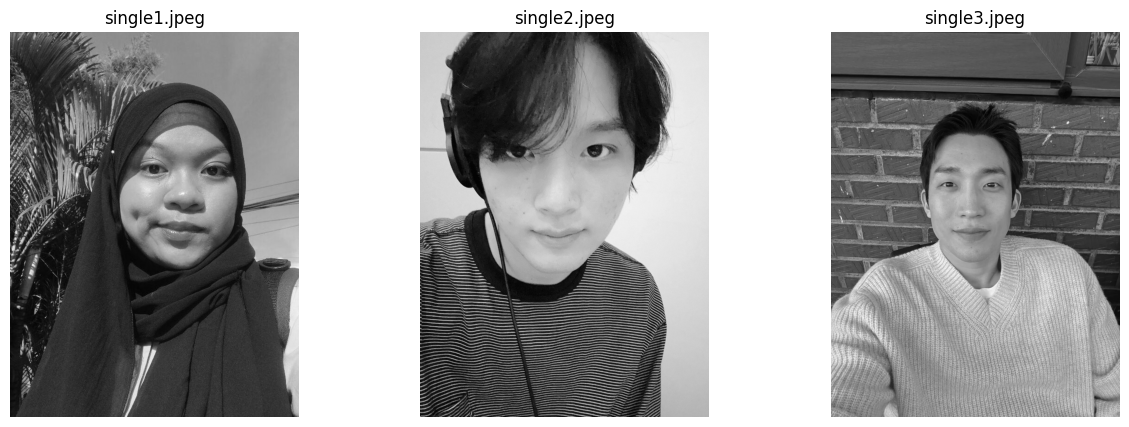

In [4]:
folder = os.path.join(path, "single_face")
files = os.listdir(folder)
plt.figure(figsize=(15,5))
for i, file in enumerate(files):
    img_path = os.path.join(folder, file)
    img = cv2.imread(img_path, 0)

    plt.subplot(1, len(files), i+1)
    plt.imshow(img, cmap='gray')
    plt.title(file)
    plt.axis('off')
plt.show()

In [5]:
haarcascades = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
face_cascade = cv2.CascadeClassifier(haarcascades)

In [6]:
deteksi_wajah = face_cascade.detectMultiScale(
    img,
    scaleFactor=1.1,
    minNeighbors=5
)

In [7]:
hasil_deteksi = []
for file in files:
    if file.endswith(('.jpg','.png','.jpeg')):
        img_path = os.path.join(folder, file)
        img = cv2.imread(img_path, 0)
        deteksi_wajah = face_cascade.detectMultiScale(img)
        for(x,y,w,h) in deteksi_wajah:
            cv2.rectangle(img,
                         (x,y),
                         (x+w, y+h),
                         (0,0,0),
                         5)
        hasil_deteksi.append((file, img))

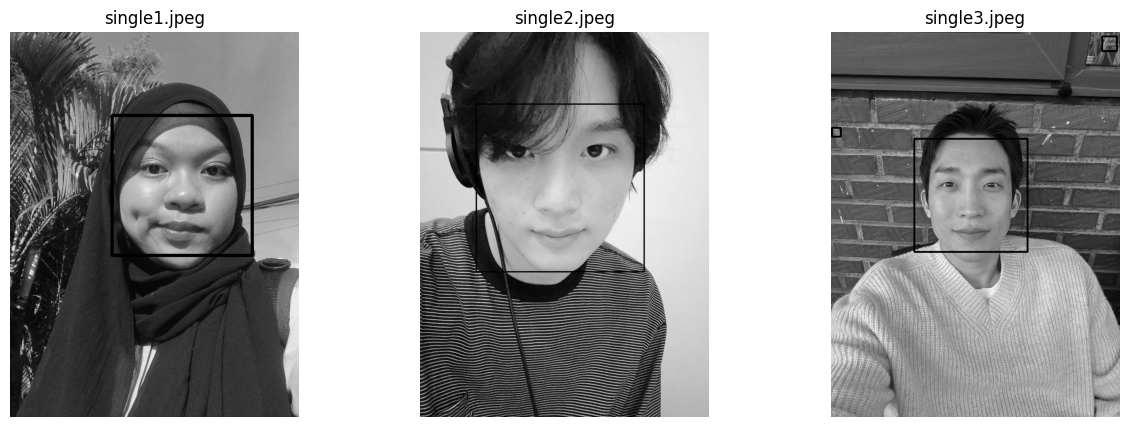

In [8]:
plt.figure(figsize=(15,5))

for i, (file, img) in enumerate(hasil_deteksi):
    plt.subplot(1, len(hasil_deteksi), i+1)
    plt.imshow(img, cmap='gray')
    plt.title(file)
    plt.axis('off')
plt.show()

Berdasarkan hasil visualisasi, sistem berhasil mendeteksi seluruh wajah pada ketiga citra dengan cukup baik yang ditandai dengan munculnya bounding box pada area wajah. Penggunaan metode Haar Cascade Classifier dan mode grayscale membantu proses deteksi tetap berjalan optimal meskipun terdapat perbedaan pada setiap gambar, seperti penggunaan hijab, headphone, maupun background yang berbeda. Hasil tersebut menunjukkan bahwa sistem mampu mengenali wajah tunggal (single face) dengan posisi wajah menghadap ke depan secara akurat.

## Deteksi banyak wajah dan kaburkan

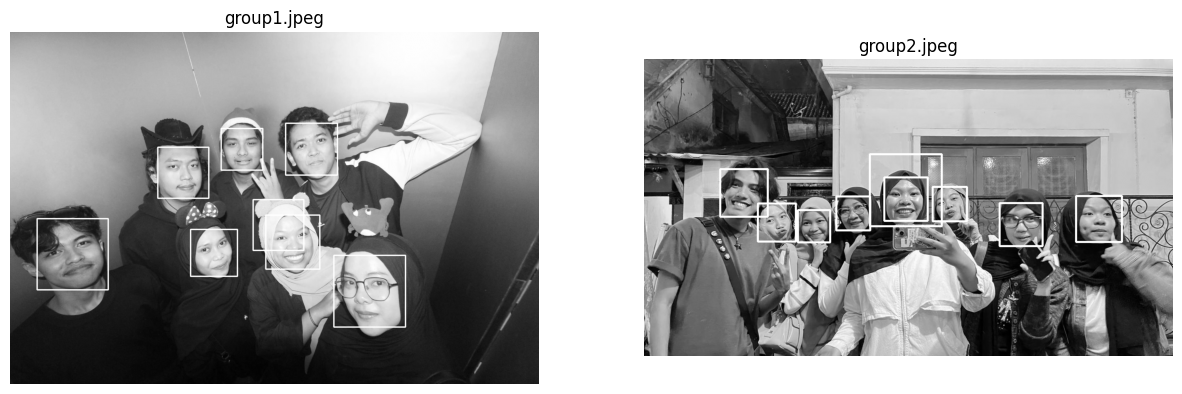

In [9]:
folder = os.path.join(path,"multi_face")
files = os.listdir(folder)
face = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
face_cascade = cv2.CascadeClassifier(face)
plt.figure(figsize=(15,10))
for i, file in enumerate(files):
    if file.endswith(('.jpg','.png','.jpeg')):
        img_path = os.path.join(folder, file)
        img = cv2.imread(img_path, 0)
        deteksi_wajah = face_cascade.detectMultiScale(
            img,
            minNeighbors=4,
            scaleFactor=1.05
        )
        for(x, y, w, h) in deteksi_wajah:
            cv2.rectangle(img,
                         (x,y),
                         (x+w, y+h),
                         (255),
                         3)

        plt.subplot(1, len(files), i+1)
        plt.imshow(img, cmap='gray')
        plt.title(file)
        plt.axis('off')
plt.show()

Berdasarkan output visualisasi pada gambar group1.jpeg dan group2.jpeg, algoritma Haar Cascade Classifier menunjukkan kemampuan yang cukup baik dalam mendeteksi banyak wajah sekaligus dalam satu frame (multi-face detection). Sistem berhasil mengidentifikasi sebagian besar wajah subjek meskipun terdapat variasi posisi, ekspresi, maupun penggunaan aksesoris seperti kacamata dan penutup kepala. Namun, pada group2.jpeg, terlihat adanya false positive atau tumpang tindih kotak deteksi pada area yang sama, yang mengindikasikan bahwa nilai scaleFactor yang rendah (1.05) membuat model sangat sensitif dalam memindai fitur wajah namun rentan terhadap deteksi ganda jika fitur wajah subjek terlalu berdekatan.

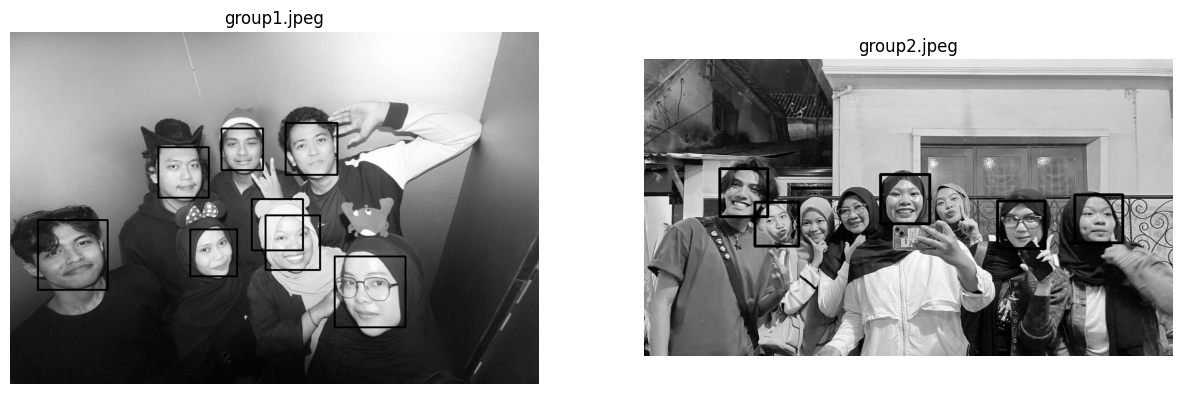

In [10]:
folder = os.path.join(path,"multi_face")
files = os.listdir(folder)
face = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
face_cascade = cv2.CascadeClassifier(face)
plt.figure(figsize=(15,10))
for i, file in enumerate(files):
    if file.endswith(('.jpg','.png','.jpeg')):
        img_path = os.path.join(folder, file)
        img = cv2.imread(img_path, 0)
        deteksi_wajah = face_cascade.detectMultiScale(
            img,
            scaleFactor=1.04,
            minNeighbors=8,
            minSize=(100,100)
        )
        for(x,y,w,h) in deteksi_wajah:
            cv2.rectangle(img,
                         (x,y),
                         (x+w, y+h),
                         (0,0,0),
                         5)
        plt.subplot(1, len(files), i+1)
        plt.imshow(img, cmap='gray')
        plt.title(file)
        plt.axis('off')
plt.show()

Berdasarkan output visualisasi pada gambar group1.jpeg dan group2.jpeg, algoritma Haar Cascade Classifier menunjukkan kemampuan yang sangat akurat dalam mengidentifikasi wajah pada area utama (foreground). Penggunaan parameter minNeighbors=8 terbukti efektif dalam menghasilkan deteksi yang bersih dan bebas dari false positive. Namun, pada group2.jpeg, terdapat 3 wajah pada area latar belakang yang tidak berhasil terdeteksi. Hal ini disebabkan oleh penerapan nilai minSize=(100,100) yang cukup tinggi; wajah subjek yang berada jauh di belakang memiliki resolusi piksel yang terlalu kecil untuk memenuhi ambang batas tersebut. Analisis ini menunjukkan bahwa model sangat stabil untuk objek jarak dekat, namun memiliki keterbatasan sensitivitas terhadap objek berukuran kecil demi menjaga ketajaman akurasi deteksi utama.

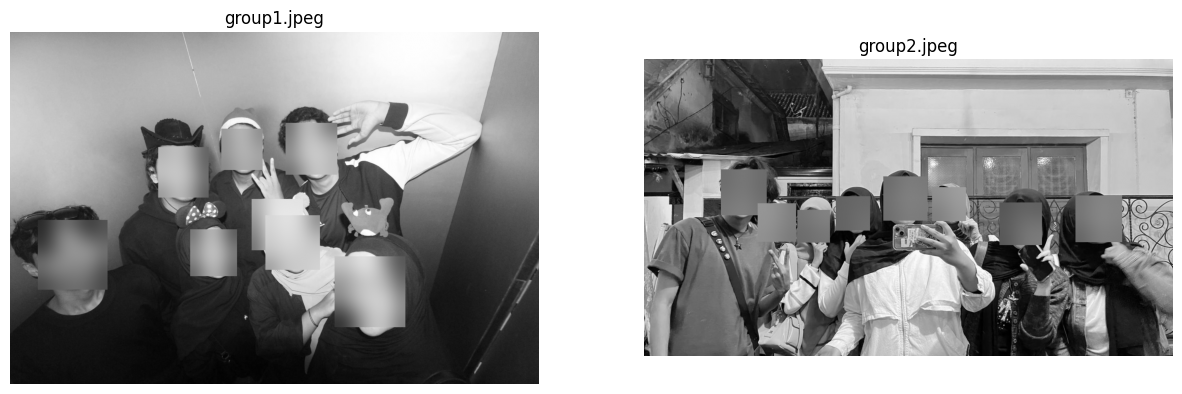

In [11]:
folder = os.path.join(path,"multi_face")
files = os.listdir(folder)
face = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
face_cascade = cv2.CascadeClassifier(face)
plt.figure(figsize=(15,10))
for i, file in enumerate(files):
    if file.endswith(('.jpg','.png','.jpeg')):
        img_path = os.path.join(folder, file)
        img = cv2.imread(img_path, 0)
        deteksi_wajah = face_cascade.detectMultiScale(
            img,
            scaleFactor=1.04,
            minNeighbors=8
        )
        for (x, y, w, h) in deteksi_wajah:
            target = img[y:y+h, x:x+w]
            blur = cv2.GaussianBlur(target, (251,251), 0)
            img[y:y+h, x:x+w] = blur
        plt.subplot(1, len(files), i+1)
        plt.imshow(img, cmap='gray')
        plt.title(file)
        plt.axis('off')
plt.show()

Berdasarkan output visualisasi pada gambar group1.jpeg dan group2.jpeg, algoritma deteksi wajah yang dikombinasikan dengan teknik Gaussian Blur telah berhasil mengidentifikasi sekaligus menyensor identitas seluruh subjek dalam gambar secara otomatis. Pada group1.jpeg, sistem mampu mendeteksi dan menutupi wajah dengan rapi meskipun posisi subjek bervariasi. Sementara pada group2.jpeg, terlihat intensitas pengaburan yang sangat efektif menggunakan kernel yang besar, sehingga informasi detail wajah benar-benar hilang untuk menjaga privasi. Meskipun terdapat beberapa area pengaburan yang saling tumpang tindih karena posisi subjek yang sangat berdekatan, fungsi utama sistem untuk melindungi identitas dalam foto berkelompok (multi-face) telah terpenuhi dengan sangat baik.

## **Persiapkan Gambar Nomor Plat Mobil dan Filter Haar**

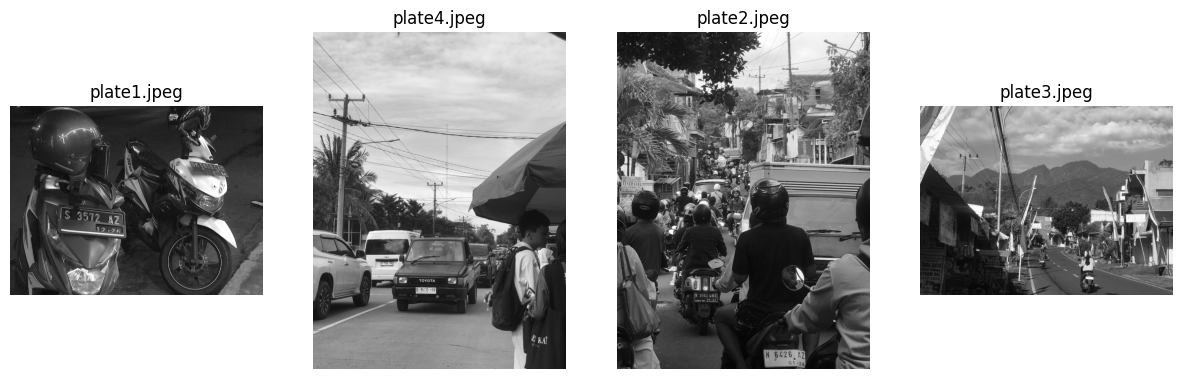

In [12]:
folder = os.path.join(path, 'plate_detection')
files = os.listdir(folder)
images = []
plt.figure(figsize=(15,10))
for i, file in enumerate(files):
    if file.endswith(('.jpg','.png','.jpeg')):
        car_plate = os.path.join(folder, file)
        img = cv2.imread(car_plate, 0)
        images.append((file, img))
        plt.subplot(1, len(files), i+1)
        plt.axis('off')
        plt.imshow(img, cmap='gray')
        plt.title(file)
plt.show()

In [13]:
hasil_deteksi = []
haarcascades = cv2.data.haarcascades + 'haarcascade_russian_plate_number.xml'
plat_cascade = cv2.CascadeClassifier(haarcascades)
for file, img in images:
    img2 = img.copy()
    print(file, img2.shape)
    deteksi_plate = plat_cascade.detectMultiScale(
        img2,
        scaleFactor=1.05,
        minNeighbors=7,
        minSize=(30,30)
    )
    hasil_deteksi.append((file, img2, deteksi_plate))

plate1.jpeg (3024, 4032)
plate4.jpeg (4032, 3024)
plate2.jpeg (2273, 1705)
plate3.jpeg (2170, 2893)


## Deteksi bagian nomor plat dari gambar

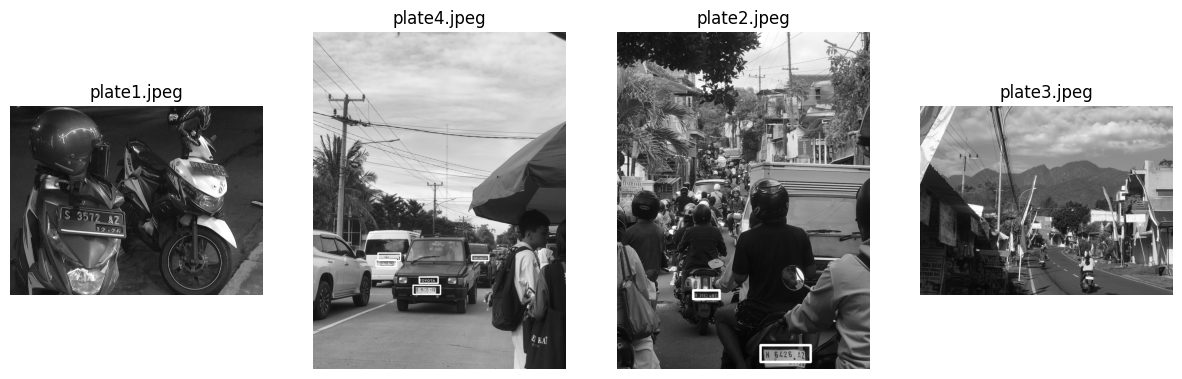

In [14]:
plt.figure(figsize=(15,10))
for i, (file, img2, deteksi_plate) in enumerate(hasil_deteksi):
    for(x,y,w,h) in deteksi_plate:
        cv2.rectangle(img2,
                     (x,y),
                     (x+w, y+h),
                     (255),
                     15)
    plt.subplot(1, len(hasil_deteksi), i+1)
    plt.axis('off')
    plt.imshow(img2, cmap='gray')
    plt.title(file)
plt.show()

Hasil pengujian menunjukkan bahwa model Haar Cascade memiliki tingkat keberhasilan sebesar 50% pada dataset ini. Deteksi berhasil dilakukan secara akurat pada plate2.jpeg dan plate4.jpeg karena posisi plat nomor yang cenderung lurus (frontal) dan memiliki kontras yang jelas terhadap bodi kendaraan. Sebaliknya, kegagalan deteksi (false negative) terjadi pada plate1.jpeg dan plate3.jpeg yang disebabkan oleh sudut kemiringan objek yang terlalu ekstrem serta jarak objek yang terlalu jauh dari kamera. Hal ini mengindikasikan bahwa model sangat bergantung pada orientasi objek dan resolusi area target; sehingga diperlukan optimasi pada parameter minNeighbors atau penggunaan teknik Image Enhancement untuk meningkatkan akurasi pada kondisi sudut pandang yang sulit.

## Blur atau kaburkan nomor plat yang telah terdeteksi

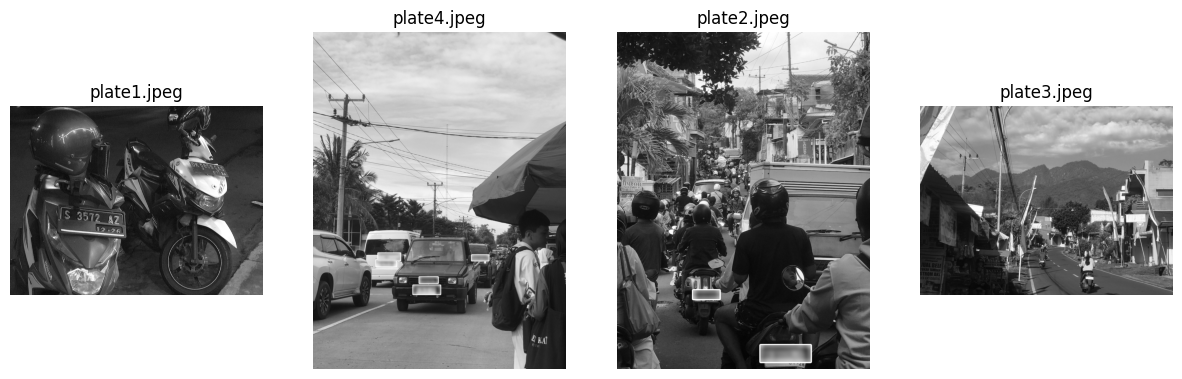

In [15]:
plt.figure(figsize=(15,10))
for i, (file, img, deteksi_plate) in enumerate(hasil_deteksi):
    img3 = img.copy()
    for(x,y,w,h) in deteksi_plate:
        target = img3[y:y+h, x:x+w]
        target = cv2.GaussianBlur(target, (101,101), 0)
        img3[y:y+h, x:x+w] = target
    plt.subplot(1, len(hasil_deteksi), i+1)
    plt.axis('off')
    plt.imshow(img3, cmap='gray')
    plt.title(file)
plt.show()

*   Privasi Berhasil: Pada gambar plate2 dan plate4, plat nomornya sudah tertutup kabur (blur). Angka dan hurufnya jadi tidak bisa dibaca sama sekali. Ini tandanya fungsi sensor privasi bekerja dengan sangat baik.
*   Kendala Deteksi: Untuk gambar plate1 dan plate3, sensornya tidak muncul. Ini bukan karena kodenya rusak, tapi karena dari awal sistem sulit mengenali plat nomornya (posisinya terlalu miring atau jaraknya terlalu jauh).

## Ekstrak Nomor Plat dari gambar plat yang telah terdeteksi

plate1.jpeg (3024, 4032)
plate4.jpeg (4032, 3024)
plate2.jpeg (2273, 1705)
plate3.jpeg (2170, 2893)


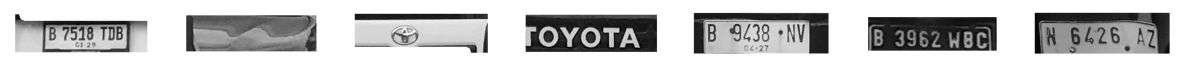

In [16]:
cropped_plate = []
for file, img, deteksi_plate in hasil_deteksi:
    img4 = img.copy()
    print(file, img4.shape)
    for(x,y,w,h) in deteksi_plate:
        plate = img4[y:y+h, x:x+w]
        cropped_plate.append(plate)
plt.figure(figsize=(15,10))
for i, plate in enumerate(cropped_plate):
    plt.subplot(1, len(cropped_plate), i + 1)
    plt.axis('off')
    plt.imshow(plate, cmap='gray')
plt.show()

*   Ekstraksi Berhasil: Sistem berhasil memisahkan objek plat nomor dari gambar kendaraan secara keseluruhan.
*   Fokus Objek: Hasil potongan (cropping) memudahkan kita untuk melihat detail angka dan huruf pada plat nomor tanpa terganggu
oleh latar belakang gambar yang ramai.
*   Walaupun hasil potongan terdapat bukan termasuk plat nomor, menandakan bahwa model dapat mendeteksi hal-hal sensitif
terkait informasi pribadi.

In [17]:
import easyocr
reader = easyocr.Reader(['en'])
for plate in cropped_plate:
    th, plate = cv2.threshold(
        plate,
        100,
        255,
        cv2.THRESH_BINARY
    )
    plate = cv2.blur(plate, (3,3))
    result = reader.readtext(plate)
    for (bbox, text, prob) in result:
        print(f'Text: {text}, Probability: {prob}')

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Text: B 7518 TDB , Probability: 0.29850391375295204
Text: TOYOTA, Probability: 0.9169858599966939
Text: B, Probability: 0.9993957002241274
Text: 9L38, Probability: 0.5434616804122925
Text: NV, Probability: 0.9948686925153443
Text: B 3962 HBCI, Probability: 0.7591442787599795
Text: X 6626, Probability: 0.5892301523140603
Text: 42, Probability: 0.7154256152368756


*   Pembacaan Berhasil: Sistem berhasil membaca beberapa plat
dengan akurasi sangat tinggi, contohnya teks "B 3962 WBC"
dan "NV" (bagian dari plat nomor) dengan nilai probabilitas di
atas 0.75 - 0.99.
*   Deteksi Tulisan Lain: Karena pada tahap sebelumnya sistem
sempat salah memotong bagian mobil (bukan plat), EasyOCR
juga ikut membaca tulisan "TOYOTA" dengan akurasi 0.91.
*   Karakter yang Kurang Jelas: Beberapa teks seperti "B 7518
TDB" memiliki nilai probabilitas rendah (0.29) karena kualitas
gambar potongan plat yang mungkin pecah atau
pencahayaannya kurang rata saat diproses.